# SZR: Dopasowanie i wizualizacja
Ten notatnik ładuje dane populacji `S, Z, R` z symulacji, wczytuje dopasowane parametry modelu SZR i wizualizuje przebieg oraz jakość dopasowania.

In [1]:
# Konfiguracja i import bibliotek
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy import stats
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

In [3]:
# Wczytanie danych i parametrów dopasowania
repo_root = Path(".").resolve().parent  # repo root
csv_path = repo_root / "notebooks" / "populations.csv"
params_path = repo_root / "notebooks" / "szr_params.json"
assert csv_path.exists(), f"Nie znaleziono CSV: {csv_path}"
assert params_path.exists(), f"Nie znaleziono pliku parametrów: {params_path}"

df = pd.read_csv(csv_path)
display(df.head())

with open(params_path, "r", encoding="utf-8") as f:
    params = json.load(f)
params

,time,S,Z,R
0,1,80,38,0
1,2,80,38,0
2,3,80,38,0
3,4,81,38,0
4,5,81,38,0


{'alpha': 0.006730670123385698,
 'beta': 0.3292028131232678,
 'gamma': 0.0966692517273283,
 'delta': 0.18781762996184725,
 'sse': 3189862.906797417}

In [4]:
# Definicja modelu SZR
# dS/dt = -beta * S * Z / N + alpha * S + delta * Z
# dZ/dt =  beta * S * Z / N - gamma * Z - delta * Z
# dR/dt =  gamma * Z

def szr_rhs(_t, y, alpha, beta, gamma, delta):
    S, Z, R = y
    N = S + Z + R
    if N <= 1e-12:
        N = 1.0
    dS = -beta * S * Z / N + alpha * S + delta * Z
    dZ = beta * S * Z / N - gamma * Z - delta * Z
    dR = gamma * Z
    return (dS, dZ, dR)

# Przygotowanie czasu i warunków początkowych
t = df["time"].to_numpy(dtype=float)
Y = df[["S","Z","R"]].to_numpy(dtype=float)
y0 = Y[0]

# Symulacja z dopasowanymi parametrami
alpha = float(params["alpha"]) ; beta = float(params["beta"]) ; gamma = float(params["gamma"]) ; delta = float(params["delta"]) 
sol = solve_ivp(lambda tt, yy: szr_rhs(tt, yy, alpha, beta, gamma, delta), t_span=(t[0], t[-1]), y0=y0, t_eval=t, rtol=1e-7, atol=1e-9)
assert sol.success, sol.message
Y_hat = sol.y.T  # shape (T, 3)
Y_hat[:5]

array([[80.        , 38.        ,  0.        ],
       [79.28896966, 35.68570366,  3.56128455],
       [78.74558802, 33.42109228,  6.90103116],
       [78.34195075, 31.22912457, 10.02521684],
       [78.05525523, 29.12562617, 12.94167979]])

In [5]:
# Obliczenie reszt i metryk RMSE, R^2
cols = ["S","Z","R"]
res = Y - Y_hat
sse = np.sum(res**2, axis=0)  # per series
n = Y.shape[0]

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

metrics = {}
for i, name in enumerate(cols):
    metrics[f"RMSE_{name}"] = rmse(Y[:, i], Y_hat[:, i])
    metrics[f"R2_{name}"] = r2(Y[:, i], Y_hat[:, i])

metrics["SSE_total"] = float(np.sum(sse))
metrics

{'RMSE_S': np.float64(32.69433943213917),
 'R2_S': np.float64(0.9988504236495197),
 'RMSE_Z': np.float64(57.27971328120393),
 'R2_Z': np.float64(-6.509339594647135),
 'RMSE_R': np.float64(31.089432183860083),
 'R2_R': np.float64(-0.9584523120640283),
 'SSE_total': 3189862.9067974174}

Saved: /home/rafal/Documents/GitHub/zombie-sim/fig/szr_fit_curve.png


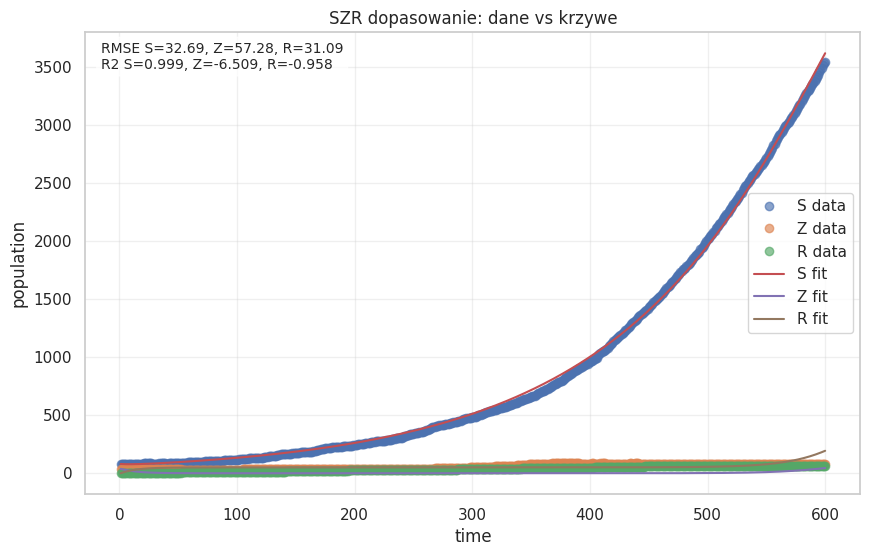

In [6]:
# Wykres danych i krzywej dopasowania
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ax.plot(t, Y[:,0], 'o', label='S data', alpha=0.65)
ax.plot(t, Y[:,1], 'o', label='Z data', alpha=0.65)
ax.plot(t, Y[:,2], 'o', label='R data', alpha=0.65)

ax.plot(t, Y_hat[:,0], '-', label='S fit')
ax.plot(t, Y_hat[:,1], '-', label='Z fit')
ax.plot(t, Y_hat[:,2], '-', label='R fit')
ax.set_xlabel('time')
ax.set_ylabel('population')
ax.set_title('SZR dopasowanie: dane vs krzywe')
ax.legend()
ax.grid(True, alpha=0.3)

# adnotacja metryk
txt = f"RMSE S={metrics['RMSE_S']:.2f}, Z={metrics['RMSE_Z']:.2f}, R={metrics['RMSE_R']:.2f}\nR2 S={metrics['R2_S']:.3f}, Z={metrics['R2_Z']:.3f}, R={metrics['R2_R']:.3f}"
ax.annotate(txt, xy=(0.02, 0.98), xycoords='axes fraction', va='top', ha='left', fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

out_dir = repo_root / 'fig'
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / 'szr_fit_curve.png'
fig.savefig(fig_path, dpi=150)
print('Saved:', fig_path)
plt.show()

Saved: /home/rafal/Documents/GitHub/zombie-sim/fig/szr_residuals.png


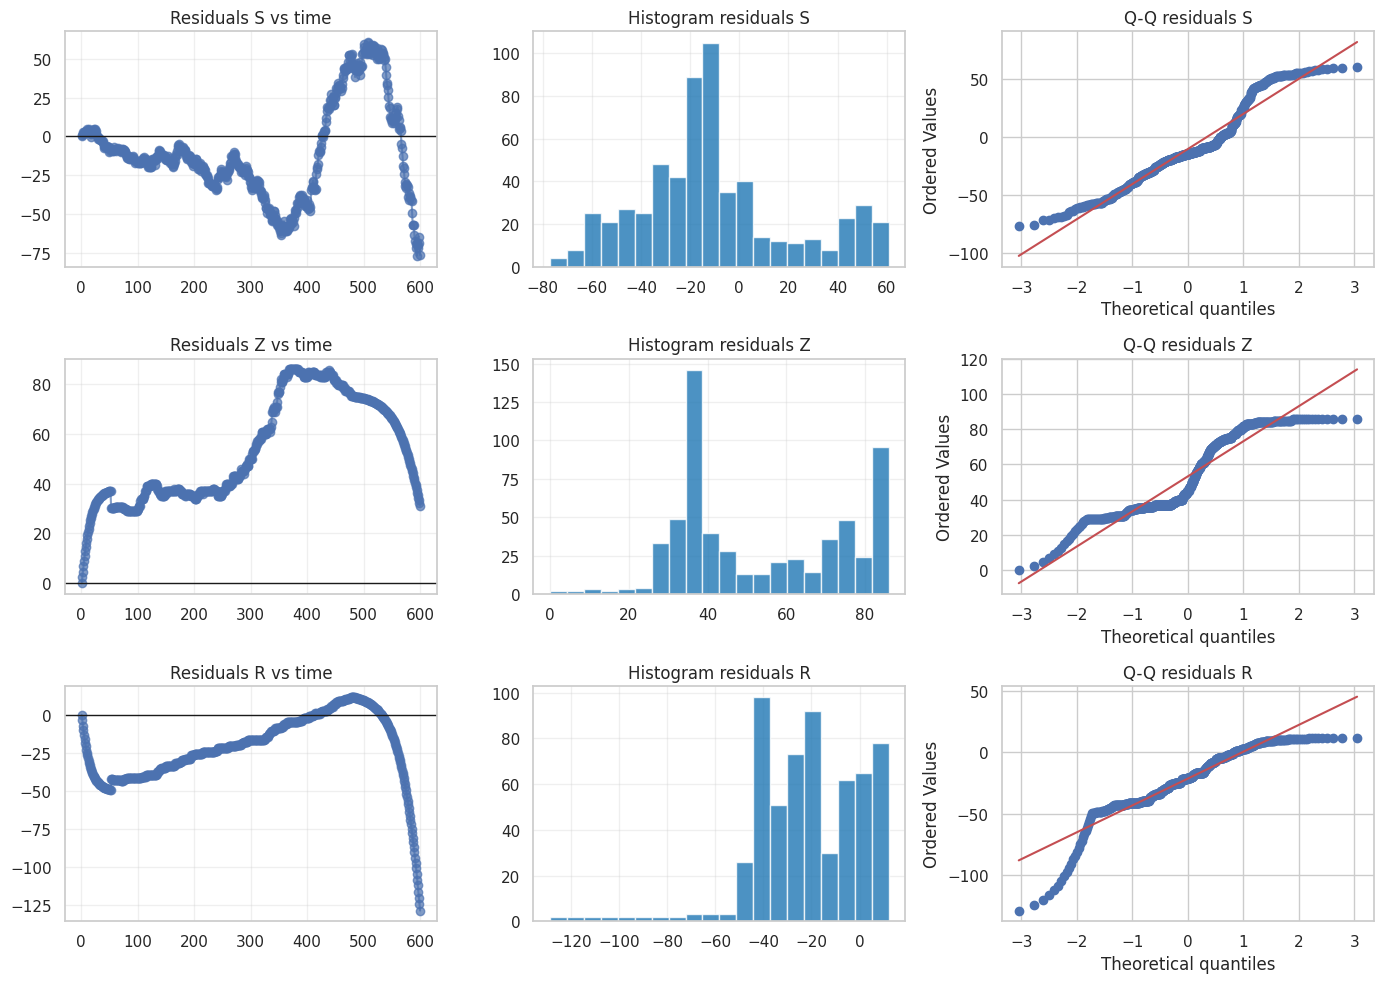

In [7]:
# Wykres reszt: serie S, Z, R
fig, axes = plt.subplots(3, 3, figsize=(14,10))
names = ['S','Z','R']
for i, name in enumerate(names):
    # reszty vs time
    axes[i,0].plot(t, res[:,i], 'o-', alpha=0.7)
    axes[i,0].axhline(0, color='k', lw=1)
    axes[i,0].set_title(f'Residuals {name} vs time')
    axes[i,0].grid(True, alpha=0.3)
    # histogram
    axes[i,1].hist(res[:,i], bins=20, alpha=0.8, color='tab:blue')
    axes[i,1].set_title(f'Histogram residuals {name}')
    axes[i,1].grid(True, alpha=0.3)
    # Q-Q plot
    stats.probplot(res[:,i], dist='norm', plot=axes[i,2])
    axes[i,2].set_title(f'Q-Q residuals {name}')
fig.tight_layout()
out_dir = repo_root / 'fig'
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / 'szr_residuals.png'
fig.savefig(fig_path, dpi=150)
print('Saved:', fig_path)
plt.show()

In [9]:
# Zapisywanie metryk i ścieżek do plików
results_dir = repo_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
metrics_path = results_dir / 'metrics_szr.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print('Saved metrics:', metrics_path)
list(results_dir.glob('*'))

Saved metrics: /home/rafal/Documents/GitHub/zombie-sim/results/metrics_szr.json


[PosixPath('/home/rafal/Documents/GitHub/zombie-sim/results/metrics_szr.json')]